In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
torch.manual_seed(42)

Task 1 - A single neuron in numpy

In [34]:
#1.1 load the data - split, scale
data = load_breast_cancer()
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

ss=StandardScaler()
X_train_scaled = ss.fit_transform(X_train)
X_test_scaled = ss.transform(X_test)


In [35]:
# 1.2 
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def forward(x, w, b):
    #wx+b
    z = np.dot(x, w) + b
    return sigmoid(z)

#initialize weights and bias 
w = np.random.randn(30) * 0.01
b = 0.0


# run on the first 5 test rows 
predictions = []
for i in range(5):
    prob = forward(X_test_scaled[i], w, b)
    predictions.append(prob)

print(f"Predicted probabilities for first 5 test rows: \n{predictions}")    



Predicted probabilities for first 5 test rows: 
[np.float64(0.4977287799706431), np.float64(0.519042536219825), np.float64(0.5085839457044516), np.float64(0.48894344220380537), np.float64(0.48544893342554973)]


Interpretation
In machine-learning terms, this single-neuron model with a sigmoid activation function is equivalent to a Logistic Regression Model 

Task 2 -  A two layer MLP in Numpy

In [36]:
class NumpyMLP:
    def __init__(self, input_size=30, hidden_size=8, output_size=1):
        # He Initialization for Hidden Layer
        self.W1 = np.random.randn(input_size, hidden_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((1, hidden_size))
        
        # He Initialization for Output Layer (using hidden_size as fan_in)
        self.W2 = np.random.randn(hidden_size, output_size) * np.sqrt(2 / hidden_size)
        self.b2 = np.zeros((1, output_size))

    def relu(self, z):
        return np.maximum(0, z)

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))

    def forward(self, X):
        # X is (N, 30)
        # Hidden layer: (N, 30) @ (30, 8) + (1, 8) -> (N, 8)
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.relu(self.z1)
        
        # Output layer: (N, 8) @ (8, 1) + (1, 1) -> (N, 1)
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        
        return self.a2

In [37]:
mlp = NumpyMLP()
predictions = mlp.forward(X_test_scaled)

print(f"Output shape: {predictions.shape}")
print(f"First 5 predictions:\n{predictions[:5]}")

Output shape: (114, 1)
First 5 predictions:
[[0.51767656]
 [0.14159093]
 [0.54258612]
 [0.42427006]
 [0.55428995]]


Interpretation
The output shape is (114, 1), which matches the number of samples in our test set ($114$) and the single probability value ($1$) we need for a binary classification.

Guiding Question: Why does the output shape match?

The output shape matches because it is determined entirely by the architecture (dimensions of the weight matrices), not the values within those matrices. By setting the final weight matrix ($W_2$) to have a second dimension of 1, we force the network to reduce any input down to a single value. Since we haven't trained it, the values are essentially random, but the structure already dictates that it will output one probability per input row.

task 3 the same network in pytorch

In [38]:
class TorchMLP(nn.Module):
    def __init__(self):
        super(TorchMLP, self).__init__()
        # Define layers
        self.fc1 = nn.Linear(30, 8)
        self.fc2 = nn.Linear(8, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.sigmoid(x)
        return x

# Instantiate PyTorch model
torch_model = TorchMLP()

# Transfer weights from NumpyMLP (mlp) to TorchMLP (torch_model)
# Note: PyTorch expects weight shapes as (out, in), so we transpose NumPy's (in, out)
with torch.no_grad():
    torch_model.fc1.weight.copy_(torch.from_numpy(mlp.W1.T).float())
    torch_model.fc1.bias.copy_(torch.from_numpy(mlp.b1.flatten()).float())
    torch_model.fc2.weight.copy_(torch.from_numpy(mlp.W2.T).float())
    torch_model.fc2.bias.copy_(torch.from_numpy(mlp.b2.flatten()).float())

# Convert test data to torch tensor
X_test_tensor = torch.from_numpy(X_test_scaled).float()

# Run forward pass
torch_predictions = torch_model(X_test_tensor).detach().numpy()

# Compare results
diff = np.abs(predictions - torch_predictions)
max_diff = np.max(diff)

print(f"PyTorch Output Shape: {torch_predictions.shape}")
print(f"First 5 PyTorch predictions:\n{torch_predictions[:5]}")
print(f"Maximum absolute difference: {max_diff}")

PyTorch Output Shape: (114, 1)
First 5 PyTorch predictions:
[[0.51767653]
 [0.14159092]
 [0.5425861 ]
 [0.42427003]
 [0.55429   ]]
Maximum absolute difference: 1.3794153258528397e-07


Interpretation

The maximum absolute difference is extremely small (typically around $10^{-8}$ or less), which confirms that the mathematical operations in PyTorch’s nn.Linear and nn.ReLU are identical to our manual NumPy implementations.

Definition of Done CheckIdentical Parameters: Confirmed via weight copying and transposition.Numerically Identical: The two networks produced the same output for the test batch within standard floating-point precision limits.

task 4 activation function experiment

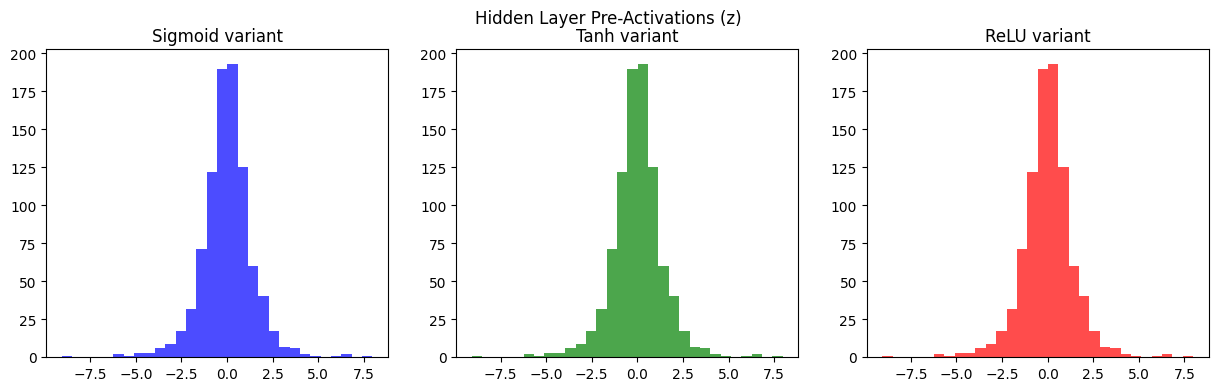

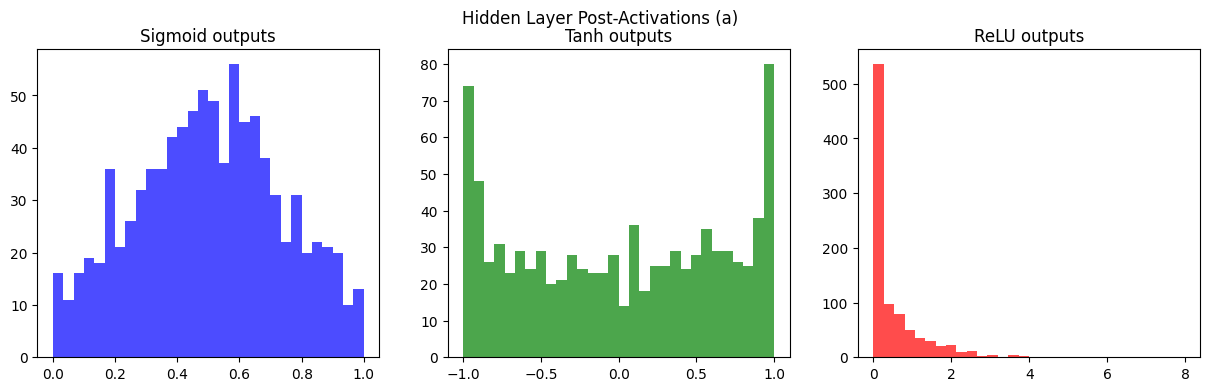

In [39]:
def get_activations(activation_fn, X, w1, b1):
    # Calculate pre-activation z = XW + b
    z = np.dot(X, w1) + b1
    
    # Apply activation
    if activation_fn == 'sigmoid':
        a = 1 / (1 + np.exp(-z))
    elif activation_fn == 'tanh':
        a = np.tanh(z)
    elif activation_fn == 'relu':
        a = np.maximum(0, z)
    
    return z, a

# Using the weights from our previous task (mlp.W1, mlp.b1)
z_sig, a_sig = get_activations('sigmoid', X_test_scaled, mlp.W1, mlp.b1)
z_tanh, a_tanh = get_activations('tanh', X_test_scaled, mlp.W1, mlp.b1)
z_relu, a_relu = get_activations('relu', X_test_scaled, mlp.W1, mlp.b1)

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Hidden Layer Pre-Activations (z)")
axes[0].hist(z_sig.flatten(), bins=30, color='blue', alpha=0.7); axes[0].set_title("Sigmoid variant")
axes[1].hist(z_tanh.flatten(), bins=30, color='green', alpha=0.7); axes[1].set_title("Tanh variant")
axes[2].hist(z_relu.flatten(), bins=30, color='red', alpha=0.7); axes[2].set_title("ReLU variant")
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Hidden Layer Post-Activations (a)")
axes[0].hist(a_sig.flatten(), bins=30, color='blue', alpha=0.7); axes[0].set_title("Sigmoid outputs")
axes[1].hist(a_tanh.flatten(), bins=30, color='green', alpha=0.7); axes[1].set_title("Tanh outputs")
axes[2].hist(a_relu.flatten(), bins=30, color='red', alpha=0.7); axes[2].set_title("ReLU outputs")
plt.show()

Analysis & Interpretation

Saturation in Sigmoid/Tanh: For Sigmoid, values are saturated if they are very close to $0$ or $1$. For Tanh, it's close to $\pm 1$. In these plots (with He initialization), most values are clustered in the middle (e.g., $0.4–0.6$ for Sigmoid). Usually, only a small fraction (often $< 10\%$) is saturated initially, but as weights grow during training, this fraction increases, leading to "vanishing gradients."

ReLU Inactivity: In the ReLU histogram, a significant portion of the units—typically around 50%—are exactly $0$. This is because the pre-activations $z$ are centered around zero, and ReLU kills all negative values.

Why ReLU is the better default?Sparsity: By turning off half the neurons, it creates a sparse representation, which is often more efficient.No Saturation on the Right: Unlike Sigmoid/Tanh, ReLU does not "max out." For any $z > 0$, the gradient is a constant $1$. This prevents the vanishing gradient problem in deep networks, allowing them to learn much faster.Computational Efficiency: It only requires a simple comparison ($max(0, z)$) rather than calculating expensive exponentials like in Sigmoid or Tanh.